In [3]:
import pandas as pd
import numpy as np
import math

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [4]:
texts_df = pd.read_csv('ru_cefr_short.csv')  
features_df = pd.read_csv('ru_cefr_short_linguistic_features.csv')  


if 'text' in features_df.columns:
    features_df = features_df.drop(columns=['text'])
if 'level_number' in features_df.columns:
    features_df = features_df.drop(columns=['level_number'])

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name = "cointegrated/rubert-tiny"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to(device)

print(f"Модель инициализирована")

Модель инициализирована


In [6]:
def get_bert_embeddings(texts, batch_size=16):
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            model_output = bert_model(**encoded)

        batch_embeddings = model_output.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

texts = texts_df['fragment'].fillna('').astype(str).tolist()
bert_embeddings = get_bert_embeddings(texts)
print(f"Размер BERT эмбеддингов: {bert_embeddings.shape}")

Размер BERT эмбеддингов: (7322, 312)


In [7]:
X_numerical = features_df.values

X_combined = np.hstack([X_numerical, bert_embeddings])
print(f"Объединенные фичи: {X_combined.shape}")
print(f"Числовые фичи: {X_numerical.shape[1]}, BERT эмбеддинги: {bert_embeddings.shape[1]}")

Объединенные фичи: (7322, 433)
Числовые фичи: 121, BERT эмбеддинги: 312


# Классификация

In [8]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Classifier', CatBoostClassifier(random_state=42, verbose=False)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB()),
    ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1, n_estimators=100))
]

In [9]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

## Классификация. С1 и С2 раздельно

In [10]:
y = texts_df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [11]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [12]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded)

        y_pred_original = le.inverse_transform(model.predict(X_test_scaled))

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: XGBoost
Обработка: LightGBM


In [13]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,SVM,0.601365,0.601365,0.513103,0.594093,0.503072
1,3,CatBoost Classifier,0.590444,0.590444,0.503005,0.582982,0.522867
2,7,XGBoost,0.571331,0.571331,0.488890,0.565797,0.541297
3,8,LightGBM,0.570648,0.570648,0.488935,0.564858,0.529010
4,0,Logistic Regression,0.541297,0.541297,0.508226,0.542969,0.602048
5,2,Random Forest,0.550853,0.550853,0.463460,0.541650,0.567235
6,5,K-Nearest Neighbors,0.491468,0.491468,0.442515,0.482690,0.692150
7,1,Decision Tree,0.395904,0.395904,0.345566,0.396877,0.853242
8,6,Naive Bayes,0.206826,0.206826,0.186839,0.179657,1.470307


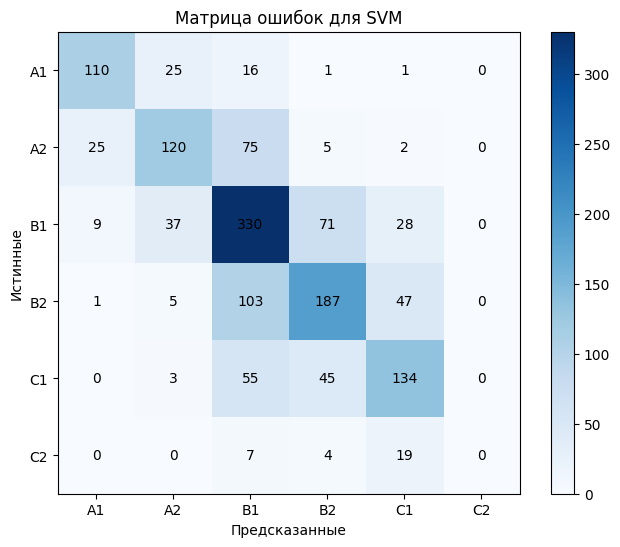

In [14]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Классификация. С1 и С2 вместе

In [15]:
y = texts_df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [16]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [17]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded)

        y_pred_original = le.inverse_transform(model.predict(X_test_scaled))

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: XGBoost
Обработка: LightGBM


In [18]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,SVM,0.615700,0.615700,0.625086,0.614634,0.479863
1,3,CatBoost Classifier,0.606826,0.606826,0.619073,0.606321,0.492833
2,7,XGBoost,0.587713,0.587713,0.599073,0.586473,0.517406
3,8,LightGBM,0.584983,0.584983,0.596296,0.584179,0.514676
4,0,Logistic Regression,0.562457,0.562457,0.576930,0.561786,0.555631
5,2,Random Forest,0.547440,0.547440,0.548848,0.544420,0.565870
6,5,K-Nearest Neighbors,0.507850,0.507850,0.514060,0.504471,0.661433
7,1,Decision Tree,0.443003,0.443003,0.443660,0.442973,0.768601
8,6,Naive Bayes,0.332423,0.332423,0.307539,0.285889,1.151536


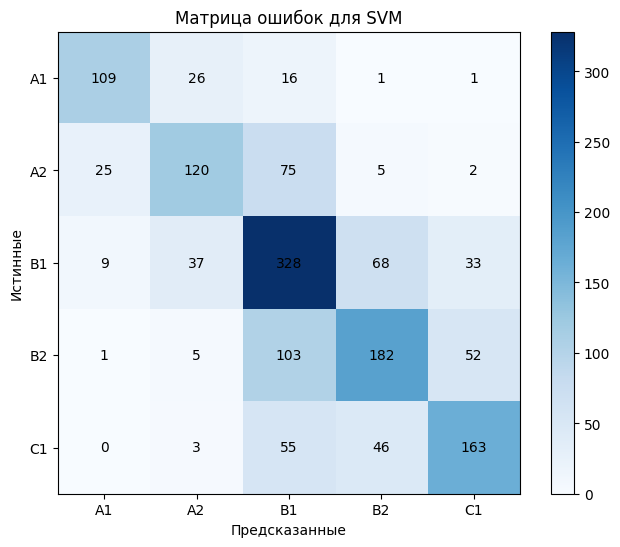

In [19]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

# Регрессия

In [20]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    # ('Random Forest', RandomForestRegressor(random_state=42, max_depth=5)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Regressor', CatBoostRegressor(random_state=42, verbose=False)),
    ('SVM', SVR()),
    ('K-Nearest Neighbors', KNeighborsRegressor()),
    # ('Naive Bayes', GaussianNB()),
    ('XGBoost', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMRegressor(random_state=42, verbose=-1, n_estimators=100))
]

## Регрессия. С1 и С2 раздельно

In [21]:
y = texts_df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [22]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [23]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 6).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [24]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'math')

        y_pred = model.predict(X_test_scaled)
        y_pred = [round(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [25]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,2,CatBoost Regressor,0.516041,0.516041,0.430079,0.508834,0.546075
1,6,LightGBM,0.507850,0.507850,0.428639,0.502796,0.557679
2,3,SVM,0.500341,0.500341,0.434832,0.496160,0.561092
3,0,Linear Regression,0.488737,0.488737,0.425296,0.486379,0.591809
4,5,XGBoost,0.484642,0.484642,0.430350,0.483023,0.595222
5,4,K-Nearest Neighbors,0.425256,0.425256,0.369855,0.416323,0.680546
6,1,Decision Tree,0.387031,0.387031,0.344184,0.387037,0.830717


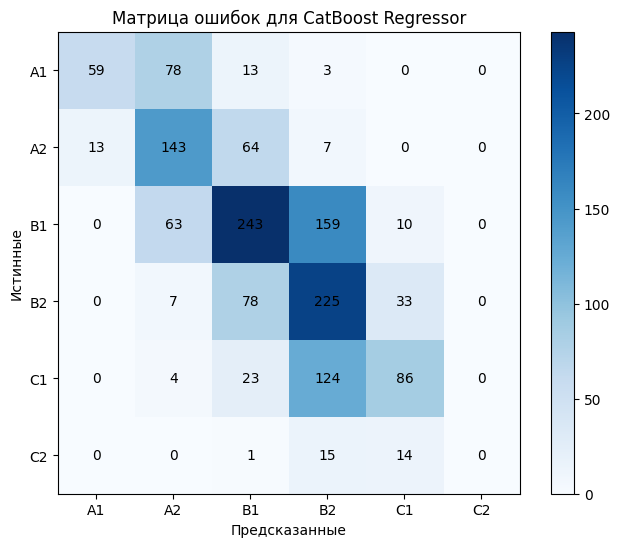

In [26]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [27]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'ceil')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.ceil(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [28]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,1,Decision Tree,0.387031,0.387031,0.344184,0.387037,0.830717
1,0,Linear Regression,0.386348,0.386348,0.318139,0.379762,0.740614
2,2,CatBoost Regressor,0.391126,0.391126,0.324359,0.376147,0.724232
3,6,LightGBM,0.389761,0.389761,0.318128,0.370756,0.724915
4,3,SVM,0.384300,0.384300,0.319763,0.370148,0.718771
5,4,K-Nearest Neighbors,0.382935,0.382935,0.314551,0.363575,0.756314
6,5,XGBoost,0.371331,0.371331,0.304475,0.358272,0.746758


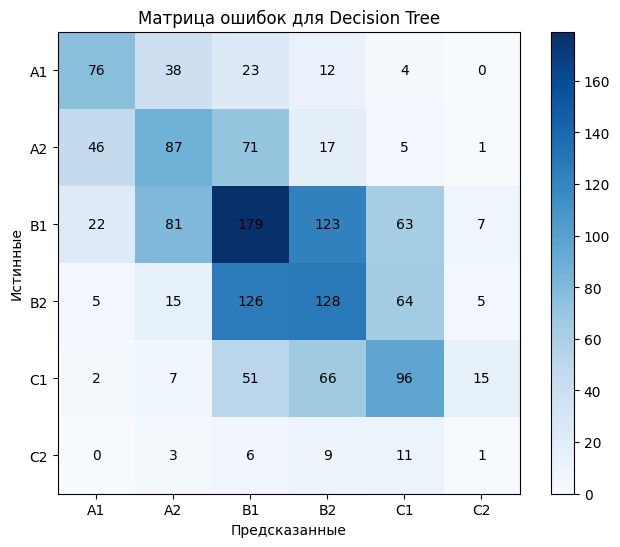

In [29]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [30]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'floor')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.floor(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [31]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,5,XGBoost,0.438225,0.438225,0.360751,0.414457,0.690102
1,3,SVM,0.440956,0.440956,0.361706,0.414367,0.669625
2,0,Linear Regression,0.418430,0.418430,0.350290,0.400721,0.705119
3,2,CatBoost Regressor,0.428669,0.428669,0.343903,0.398131,0.688737
4,6,LightGBM,0.425939,0.425939,0.345041,0.396084,0.688055
5,1,Decision Tree,0.387031,0.387031,0.344184,0.387037,0.830717
6,4,K-Nearest Neighbors,0.405461,0.405461,0.321745,0.376187,0.733106


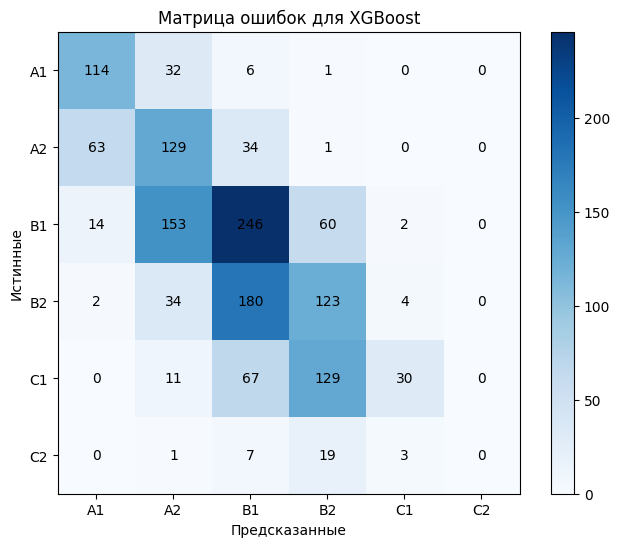

In [32]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Регрессия. С1 и С2 вместе

In [33]:
y = texts_df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [34]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [35]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 5).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [36]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'math')

        y_pred = model.predict(X_test_scaled)
        y_pred = [round(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [37]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,2,CatBoost Regressor,0.523549,0.523549,0.519132,0.517446,0.520137
1,6,LightGBM,0.519454,0.519454,0.511900,0.514120,0.529010
2,0,Linear Regression,0.509215,0.509215,0.505364,0.508483,0.546075
3,3,SVM,0.509898,0.509898,0.503726,0.508274,0.534471
4,5,XGBoost,0.500341,0.500341,0.498987,0.497458,0.565870
5,4,K-Nearest Neighbors,0.432082,0.432082,0.420772,0.422208,0.662116
6,1,Decision Tree,0.393174,0.393174,0.394404,0.391831,0.832082


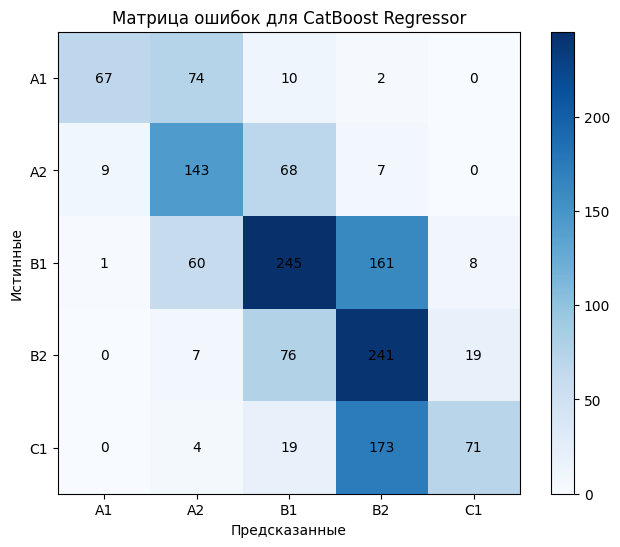

In [38]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [39]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'ceil')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.ceil(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [40]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,0,Linear Regression,0.425256,0.425256,0.393047,0.411227,0.679181
1,2,CatBoost Regressor,0.421160,0.421160,0.389280,0.403567,0.672355
2,3,SVM,0.412969,0.412969,0.376867,0.394657,0.681229
3,6,LightGBM,0.414334,0.414334,0.372825,0.394424,0.681229
4,1,Decision Tree,0.393174,0.393174,0.394404,0.391831,0.832082
5,5,XGBoost,0.395222,0.395222,0.367630,0.382497,0.717406
6,4,K-Nearest Neighbors,0.397270,0.397270,0.366234,0.379605,0.732423


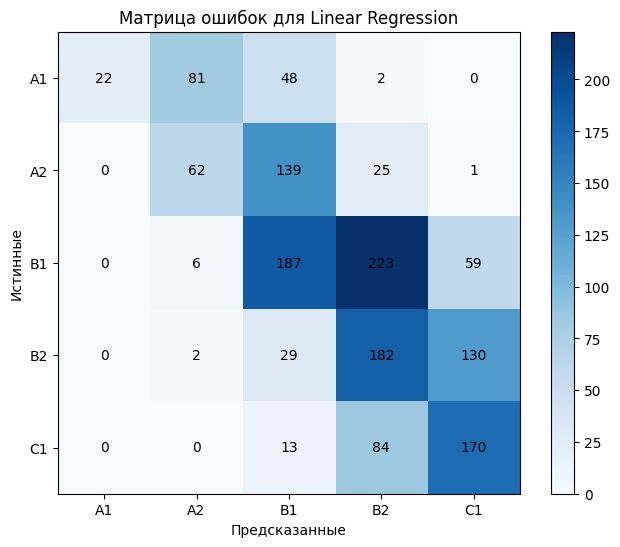

In [41]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [42]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'floor')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.floor(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [43]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.438908,0.438908,0.422719,0.410131,0.656655
1,0,Linear Regression,0.421843,0.421843,0.416817,0.401901,0.683959
2,2,CatBoost Regressor,0.437543,0.437543,0.415399,0.400231,0.656655
3,6,LightGBM,0.431399,0.431399,0.403494,0.393689,0.668259
4,1,Decision Tree,0.393174,0.393174,0.394404,0.391831,0.832082
5,5,XGBoost,0.419113,0.419113,0.398255,0.390001,0.708532
6,4,K-Nearest Neighbors,0.407509,0.407509,0.378036,0.372093,0.713993


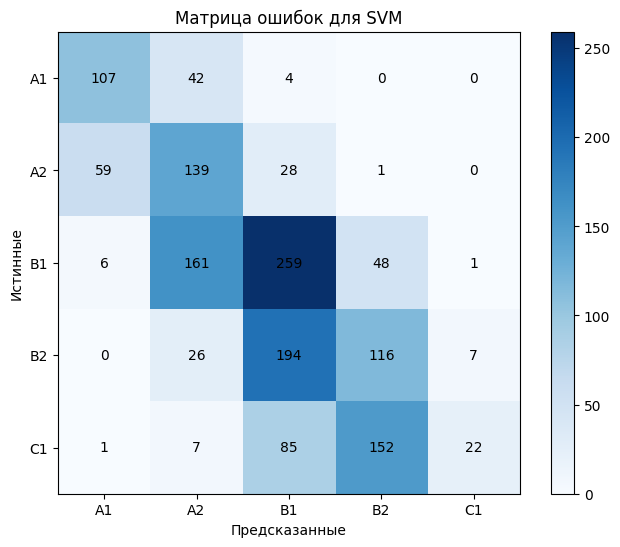

In [44]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()